# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [1]:
import pandas as pd


In [2]:
# cargar archivos
orders    = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog   = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [3]:
# explorar datasets
for nombre, df in [('orders', orders), ('catalog', catalog), ('marketing', marketing)]:
    print(f"\n===== {nombre} — {df.shape} =====")
    print(df.head(3))
    print(df.dtypes)
    print("Nulos:\n", df.isna().sum())# tu código aquí


===== orders — (25100, 12) =====
  id_pedido id_usuario fecha_hora_pedido       pais dispositivo  \
0   order_0  user_6993        2025-05-22  Argentina     desktop   
1   order_1  user_1329        2025-06-15     Mexico     desktop   
2   order_2  user_3194        2025-05-02  Argentina     desktop   

  fuente_referencia       nombre_producto categoria_producto  cantidad  \
0           organic       Jacket-Winter-M               Moda       2.0   
1       paid_search  Tablet-Standard-64GB        Electronica       1.0   
2            social        Blender-XL-Red              Hogar       2.0   

   precio_unitario  monto_descuento  monto_total  
0           332.69              0.0       665.37  
1           176.86              5.0       171.86  
2           102.99             10.0       195.99  
id_pedido              object
id_usuario             object
fecha_hora_pedido      object
pais                   object
dispositivo            object
fuente_referencia      object
nombre_producto 

---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [4]:
# ============ LIMPIEZA ORDERS ============
orders = orders.drop_duplicates()

columnas_clave = ['cantidad', 'precio_unitario', 'monto_descuento',
                  'nombre_producto', 'categoria_producto']
orders = orders.dropna(subset=columnas_clave)

orders = orders[(orders['cantidad'] > 0) & (orders['cantidad'] <= 10)]

orders['pais'] = orders['pais'].str.strip().str.capitalize()
orders['categoria_producto'] = orders['categoria_producto'].replace({'Electronica': 'Electrónica'})

orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'])
orders['cantidad'] = orders['cantidad'].astype(int)

orders['pais'] = orders['pais'].fillna('Desconocido')
orders['dispositivo'] = orders['dispositivo'].fillna('Desconocido')

# ============ LIMPIEZA CATALOG ============
catalog['categoria_producto'] = catalog['categoria_producto'].str.strip()

# ============ LIMPIEZA MARKETING ============
marketing['canal'] = marketing['canal'].fillna(
    marketing['id_campaña'].str.rsplit('_', n=1).str[0]
)
marketing['fecha'] = pd.to_datetime(marketing['fecha'])

print("✅ Limpieza aplicada")

✅ Limpieza aplicada


In [5]:
print(orders.shape)
print(orders.isna().sum())
print(f"Revenue limpio: ${orders['monto_total'].sum():,.2f}")

(24906, 12)
id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
dtype: int64
Revenue limpio: $9,610,018.94


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [6]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [7]:
# Cruzar orders con catalog para traer el costo_unitario de cada producto
orders_cost = orders.merge(
    catalog[['nombre_producto', 'costo_unitario']],
    on='nombre_producto',
    how='left'
)

# Costo de cada línea de pedido = costo unitario × cantidad
orders_cost['costo_total_linea'] = orders_cost['costo_unitario'] * orders_cost['cantidad']

# --- KPIs de rentabilidad ---
revenue_total   = orders_cost['monto_total'].sum()
costo_total     = orders_cost['costo_total_linea'].sum()
marketing_total = marketing['gasto'].sum()
profit          = revenue_total - costo_total - marketing_total

print("===== RENTABILIDAD DEL NEGOCIO =====")
print(f"Revenue total:       ${revenue_total:,.2f}")
print(f"Costo de productos:  ${costo_total:,.2f}")
print(f"Gasto en marketing:  ${marketing_total:,.2f}")
print(f"{'-'*40}")
print(f"PROFIT:              ${profit:,.2f}")
print(f"Margen de profit:    {profit/revenue_total*100:.1f}%")# tu código aquí


===== RENTABILIDAD DEL NEGOCIO =====
Revenue total:       $9,610,018.94
Costo de productos:  $3,828,869.01
Gasto en marketing:  $2,871,843.53
----------------------------------------
PROFIT:              $2,909,306.40
Margen de profit:    30.3%


In [8]:
# Ticket promedio POR ORDEN (no por línea)
# Una orden puede tener varias líneas, así que agrupamos por id_pedido
ticket_por_orden = orders.groupby('id_pedido')['monto_total'].sum()
ticket_promedio  = ticket_por_orden.mean()

# Cantidad promedio de productos por orden
cantidad_por_orden = orders.groupby('id_pedido')['cantidad'].sum()
cantidad_promedio  = cantidad_por_orden.mean()

# Producto más vendido (por unidades)
producto_top = orders.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False)

# Gasto en marketing por canal
gasto_por_canal = marketing.groupby('canal')['gasto'].sum().sort_values(ascending=False)

print("===== COMPORTAMIENTO DE VENTAS =====")
print(f"Ticket promedio por orden:        ${ticket_promedio:,.2f}")
print(f"Cantidad promedio prod. por orden: {cantidad_promedio:.2f}")
print(f"\nProducto más vendido: {producto_top.index[0]} ({producto_top.iloc[0]:,} unidades)")
print(f"\nUnidades vendidas por producto:\n{producto_top}")
print(f"\nGasto en marketing por canal:\n{gasto_por_canal}")

===== COMPORTAMIENTO DE VENTAS =====
Ticket promedio por orden:        $385.85
Cantidad promedio prod. por orden: 1.50

Producto más vendido: Vacuum-Pro-Black (6,284 unidades)

Unidades vendidas por producto:
nombre_producto
Vacuum-Pro-Black        6284
Blender-XL-Red          6279
Jacket-Winter-M         6256
Sneakers-Urban-42       6172
Laptop-Gaming-16GB      4198
Tablet-Standard-64GB    4153
Phone-Pro-128GB         4140
Name: cantidad, dtype: int64

Gasto en marketing por canal:
canal
social         976818.37
organic        972650.96
paid_search    922374.20
Name: gasto, dtype: float64


---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [9]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión a la base de datos (credenciales reemplazadas por seguridad)
# ======================
db_config = {
    'user': 'TU_USUARIO',
    'pwd': 'TU_PASSWORD',
    'host': 'TU_HOST',
    'port': 5432,
    'db': 'TU_BASE_DE_DATOS'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [10]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [11]:
print(events['nombre_evento'].value_counts())

first_visit         29957
add_to_cart         24157
select_item         23887
begin_checkout      17971
add_payment_info    12018
purchase            12010
Name: nombre_evento, dtype: int64


In [12]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios
FROM events
GROUP BY nombre_evento
ORDER BY usuarios DESC;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [13]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH funnel AS (
    SELECT
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS usuarios,
        CASE nombre_evento
            WHEN 'first_visit'      THEN 1
            WHEN 'select_item'      THEN 2
            WHEN 'add_to_cart'      THEN 3
            WHEN 'begin_checkout'   THEN 4
            WHEN 'add_payment_info' THEN 5
            WHEN 'purchase'         THEN 6
        END AS orden_funnel
    FROM events
    GROUP BY nombre_evento
)
SELECT
    nombre_evento,
    usuarios,
    LAG(usuarios) OVER (ORDER BY orden_funnel) AS usuarios_etapa_anterior,
    ROUND(
        100.0 * usuarios / LAG(usuarios) OVER (ORDER BY orden_funnel),
        2
    ) AS conversion_vs_anterior_pct,
    ROUND(
        100.0 * usuarios / FIRST_VALUE(usuarios) OVER (ORDER BY orden_funnel),
        2
    ) AS conversion_total_pct
FROM funnel
ORDER BY orden_funnel;
'''
conversion = pd.read_sql(query_conversion, con=engine)
conversion

,nombre_evento,usuarios,usuarios_etapa_anterior,conversion_vs_anterior_pct,conversion_total_pct
0,first_visit,7796,NaN,NaN,100.00
1,select_item,7582,7796.0,97.26,97.26
2,add_to_cart,7634,7582.0,100.69,97.92
3,begin_checkout,7208,7634.0,94.42,92.46
4,add_payment_info,6250,7208.0,86.71,80.17
5,purchase,6240,6250.0,99.84,80.04


**Nota sobre la anomalía del funnel:** La conversión de select_item → add_to_cart 
supera el 100% (100.69%), lo cual a primera vista parece imposible. Esto NO es un 
error de cálculo, sino una característica esperable de los funnels reales: al contar 
usuarios únicos por evento de forma independiente, algunos usuarios llegan a 
add_to_cart sin haber pasado por select_item (vía enlaces directos, carritos 
guardados o recompras). También podría reflejar un registro incompleto del evento 
select_item. En cualquier caso, no afecta la conclusión principal, ya que la fuga 
relevante del funnel ocurre claramente más adelante, entre begin_checkout y 
add_payment_info (caída del 13%).

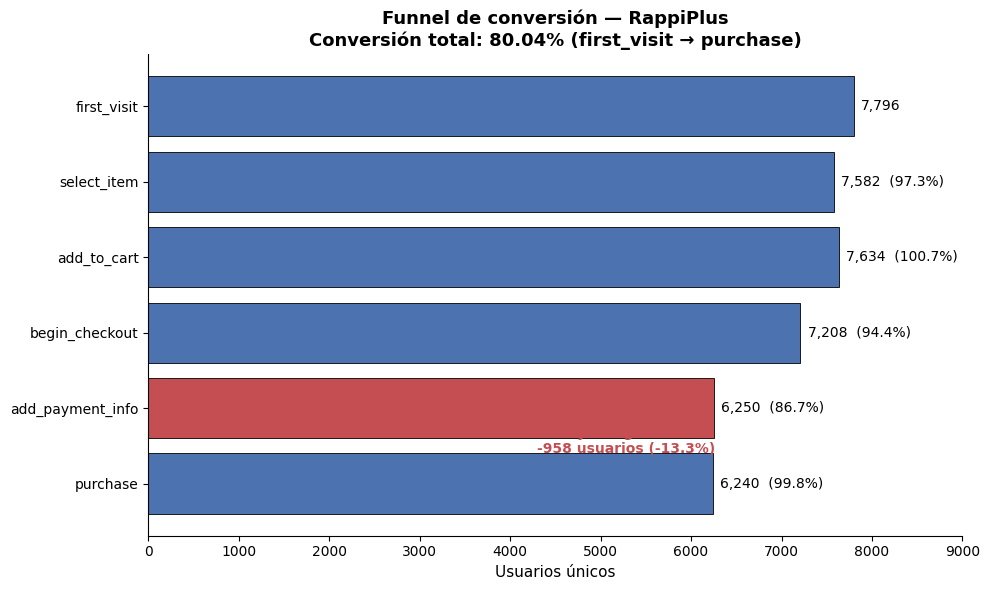

In [14]:
import matplotlib.pyplot as plt

# Datos del funnel (en orden lógico del usuario)
etapas = ['first_visit', 'select_item', 'add_to_cart',
          'begin_checkout', 'add_payment_info', 'purchase']
usuarios = [7796, 7582, 7634, 7208, 6250, 6240]

# Conversión vs etapa anterior (para anotar la caída)
conv_vs_anterior = [None, 97.26, 100.69, 94.42, 86.71, 99.84]

fig, ax = plt.subplots(figsize=(10, 6))

# Color: resaltar en rojo la etapa donde está la mayor fuga
colores = ['#4c72b0'] * len(etapas)
colores[4] = '#c44e52'  # add_payment_info en rojo

barras = ax.barh(range(len(etapas)), usuarios, color=colores, edgecolor='black', linewidth=0.6)
ax.set_yticks(range(len(etapas)))
ax.set_yticklabels(etapas)
ax.invert_yaxis()  # first_visit arriba

# Etiquetas: usuarios + % de conversión vs etapa anterior
for i, (barra, u, c) in enumerate(zip(barras, usuarios, conv_vs_anterior)):
    etiqueta = f'{u:,}'
    if c is not None:
        etiqueta += f'  ({c:.1f}%)'
    ax.text(u + 80, i, etiqueta, va='center', fontsize=10)

# Anotar la fuga principal
ax.annotate('⚠️ Mayor fuga:\n-958 usuarios (-13.3%)',
            xy=(6250, 4), xytext=(4300, 4.6),
            fontsize=10, color='#c44e52', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c44e52'))

ax.set_xlabel('Usuarios únicos', fontsize=11)
ax.set_title('Funnel de conversión — RappiPlus\nConversión total: 80.04% (first_visit → purchase)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 9000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [15]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [16]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECt *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [17]:
query_check = '''
SELECT dias_despues_registro, COUNT(*) AS registros, SUM(activo) AS activos
FROM user_activity
GROUP BY dias_despues_registro
ORDER BY dias_despues_registro;
'''
check = pd.read_sql(query_check, con=engine)
check


,dias_despues_registro,registros,activos
0,7,8000,3360.0
1,14,8000,3355.0
2,21,8000,3350.0
3,28,8000,3250.0


In [18]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH base AS (
    SELECT
        u.id_usuario,
        TO_CHAR(CAST(u.fecha_registro AS DATE), 'YYYY-MM') AS cohorte,
        a.dias_despues_registro,
        a.activo
    FROM users u
    LEFT JOIN user_activity a
        ON u.id_usuario = a.id_usuario
)
SELECT
    cohorte,
    COUNT(DISTINCT id_usuario) AS clientes_iniciales,
    SUM(CASE WHEN dias_despues_registro = 7  AND activo = 1 THEN 1 ELSE 0 END) AS retenido_w1,
    SUM(CASE WHEN dias_despues_registro = 14 AND activo = 1 THEN 1 ELSE 0 END) AS retenido_w2,
    SUM(CASE WHEN dias_despues_registro = 21 AND activo = 1 THEN 1 ELSE 0 END) AS retenido_w3,
    ROUND(100.0 * SUM(CASE WHEN dias_despues_registro = 7  AND activo = 1 THEN 1 ELSE 0 END)
          / COUNT(DISTINCT id_usuario), 2) AS semana_1,
    ROUND(100.0 * SUM(CASE WHEN dias_despues_registro = 14 AND activo = 1 THEN 1 ELSE 0 END)
          / COUNT(DISTINCT id_usuario), 2) AS semana_2,
    ROUND(100.0 * SUM(CASE WHEN dias_despues_registro = 21 AND activo = 1 THEN 1 ELSE 0 END)
          / COUNT(DISTINCT id_usuario), 2) AS semana_3
FROM base
GROUP BY cohorte
ORDER BY cohorte;
'''


# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,clientes_iniciales,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01,1627,697,668,656,42.84,41.06,40.32
1,2025-02,1444,611,609,635,42.31,42.17,43.98
2,2025-03,1636,677,705,690,41.38,43.09,42.18
3,2025-04,1606,680,697,663,42.34,43.40,41.28
4,2025-05,1687,695,676,706,41.20,40.07,41.85


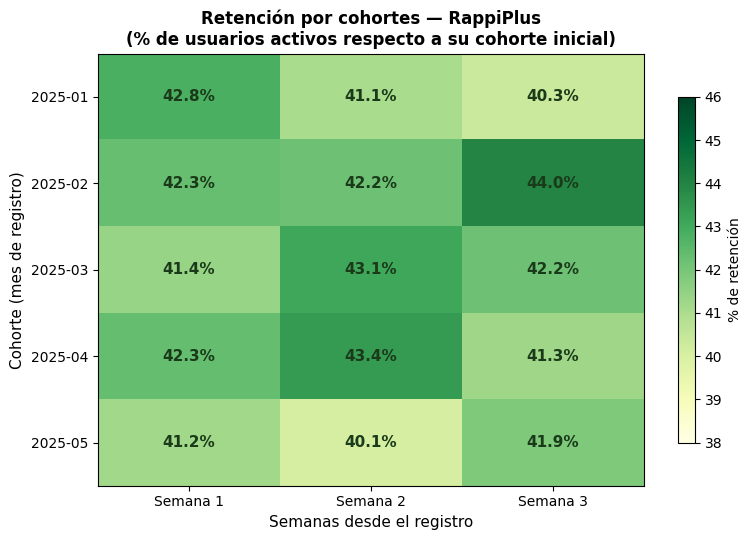

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de la tabla de cohortes (porcentajes de retención)
cohortes = ['2025-01', '2025-02', '2025-03', '2025-04', '2025-05']
semanas = ['Semana 1', 'Semana 2', 'Semana 3']

retencion = np.array([
    [42.84, 41.06, 40.32],
    [42.31, 42.17, 43.98],
    [41.38, 43.09, 42.18],
    [42.34, 43.40, 41.28],
    [41.20, 40.07, 41.85],
])

fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(retencion, cmap='YlGn', aspect='auto', vmin=38, vmax=46)

# Ejes
ax.set_xticks(range(len(semanas)))
ax.set_xticklabels(semanas)
ax.set_yticks(range(len(cohortes)))
ax.set_yticklabels(cohortes)
ax.set_xlabel('Semanas desde el registro', fontsize=11)
ax.set_ylabel('Cohorte (mes de registro)', fontsize=11)

# Escribir el valor dentro de cada celda
for i in range(len(cohortes)):
    for j in range(len(semanas)):
        ax.text(j, i, f'{retencion[i, j]:.1f}%',
                ha='center', va='center', fontsize=11, fontweight='bold', color='#1a3a1a')

ax.set_title('Retención por cohortes — RappiPlus\n(% de usuarios activos respecto a su cohorte inicial)',
             fontsize=12, fontweight='bold')

# Barra de color
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('% de retención', fontsize=10)

plt.tight_layout()
plt.show()

**Interpretación:** El heatmap muestra una retención muy estable, en torno al 42%, 
en todas las cohortes y semanas (sin caídas ni picos marcados). Esto indica que el 
comportamiento de retención es estructural y consistente mes a mes. El hallazgo 
clave no está en la variación entre cohortes, sino en el nivel: ~42% se mantiene 
activo, lo que implica que cerca del 58% de los usuarios no regresa tras registrarse 
— la mayor oportunidad de mejora está en la primera semana (onboarding).


---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---

**Hipótesis estadística**
- H₀ (nula): No hay diferencia real en la conversión entre control y tratamiento. 
  Cualquier diferencia observada es producto del azar.
- H₁ (alternativa): Sí hay una diferencia real en la conversión entre los dos grupos.

**Test estadístico:** z-test de proporciones (dos colas), adecuado para comparar 
dos proporciones (equivalente a un chi-cuadrado).

**Nivel de significancia α:** 0.05 — probabilidad máxima de cometer un error tipo I 
(rechazar H₀ siendo verdadera).

**Resultados:**
- Conversión control: 15.69%  | Conversión tratamiento: 16.29%
- Estadístico z = -0.81
- Valor p = 0.4161

**Conclusión:** Como p = 0.4161 > 0.05, NO se rechaza H₀. La diferencia de 0.6 puntos 
porcentuales no es estadísticamente significativa y puede atribuirse al azar. No hay 
evidencia de que la nueva UI mejore la conversión, por lo que no se recomienda 
implementarla con base en estos datos.

In [20]:
experimento = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')
print(experimento.shape)
print(experimento.head())
print(experimento.columns.tolist())# tu código aquí



(10000, 7)
   id_usuario     variante  convirtio dispositivo       pais  duracion_sesion  \
0  exp_user_0  tratamiento          0      mobile  Argentina           114.41   
1  exp_user_1  tratamiento          0     desktop     Mexico           170.03   
2  exp_user_2      control          1      mobile   Colombia           140.21   
3  exp_user_3  tratamiento          0      mobile   Colombia           151.45   
4  exp_user_4  tratamiento          0     desktop     Mexico           299.96   

    timestamp  
0  2025-03-28  
1  2025-01-15  
2  2025-03-18  
3  2025-06-03  
4  2025-01-12  
['id_usuario', 'variante', 'convirtio', 'dispositivo', 'pais', 'duracion_sesion', 'timestamp']


In [21]:
# ¿Cuántos usuarios hay en cada grupo y cuál es su conversión?
resumen = experimento.groupby('variante')['convirtio'].agg(['count', 'sum', 'mean'])
resumen.columns = ['usuarios', 'conversiones', 'tasa_conversion']
print(resumen)

             usuarios  conversiones  tasa_conversion
variante                                            
control          4965           779         0.156898
tratamiento      5035           820         0.162860


In [22]:
from statsmodels.stats.proportion import proportions_ztest

# Datos para el test
conversiones = [779, 820]          # éxitos en cada grupo (control, tratamiento)
usuarios     = [4965, 5035]        # total de usuarios en cada grupo

# Test z de proporciones (dos colas)
z_stat, p_value = proportions_ztest(count=conversiones, nobs=usuarios)

alpha = 0.05

print("===== TEST A/B: UI del checkout =====")
print(f"Conversión control:     {779/4965:.4f} (15.69%)")
print(f"Conversión tratamiento: {820/5035:.4f} (16.29%)")
print(f"\nEstadístico z: {z_stat:.4f}")
print(f"Valor p:       {p_value:.4f}")
print(f"Alpha:         {alpha}")
print(f"\n{'-'*45}")
if p_value < alpha:
    print("✅ Rechazamos H₀: la diferencia ES estadísticamente significativa.")
    print("   La nueva UI tiene un efecto real sobre la conversión.")
else:
    print("❌ No rechazamos H₀: la diferencia NO es estadísticamente significativa.")
    print("   No hay evidencia de que la nueva UI mejore la conversión.")

===== TEST A/B: UI del checkout =====
Conversión control:     0.1569 (15.69%)
Conversión tratamiento: 0.1629 (16.29%)

Estadístico z: -0.8133
Valor p:       0.4161
Alpha:         0.05

---------------------------------------------
❌ No rechazamos H₀: la diferencia NO es estadísticamente significativa.
   No hay evidencia de que la nueva UI mejore la conversión.


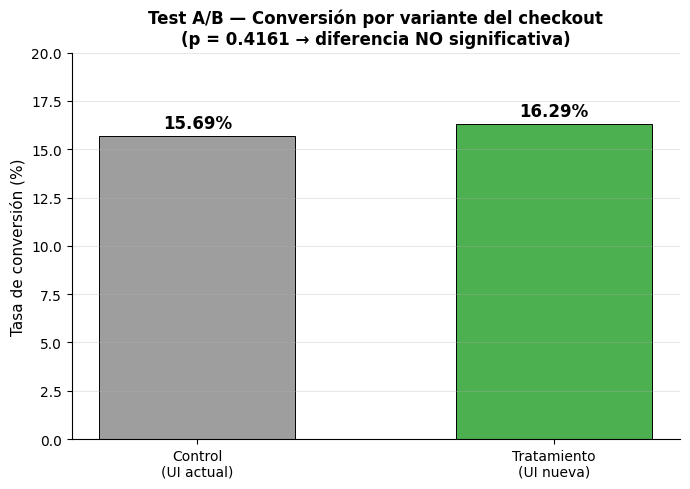

In [23]:
import matplotlib.pyplot as plt

# Datos del experimento
variantes = ['Control\n(UI actual)', 'Tratamiento\n(UI nueva)']
tasas = [15.69, 16.29]
colores = ['#9e9e9e', '#4caf50']

fig, ax = plt.subplots(figsize=(7, 5))
barras = ax.bar(variantes, tasas, color=colores, width=0.55, edgecolor='black', linewidth=0.7)

# Etiquetas con el valor encima de cada barra
for barra, tasa in zip(barras, tasas):
    ax.text(barra.get_x() + barra.get_width()/2, tasa + 0.2,
            f'{tasa:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Tasa de conversión (%)', fontsize=11)
ax.set_title('Test A/B — Conversión por variante del checkout\n(p = 0.4161 → diferencia NO significativa)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:** Aunque el grupo tratamiento muestra una conversión ligeramente 
mayor (16.29% vs 15.69%), la gráfica evidencia que ambas barras son casi idénticas. 
El z-test confirma que esta diferencia de 0.6 puntos no es estadísticamente 
significativa (p = 0.4161 > 0.05): es indistinguible del azar. Por lo tanto, no hay 
evidencia de que la nueva UI mejore la conversión.

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

Conclusiones — Proyecto RappiPlus
Contexto: El objetivo era evaluar si RappiPlus cumple su propósito de aumentar el valor por usuario, respondiendo seis preguntas de negocio a partir de datos de pedidos, catálogo, marketing, comportamiento de usuarios y un experimento A/B.
1. ¿Podemos confiar en los datos? Sí, tras la limpieza. El dataset original de pedidos tenía 25,100 filas con problemas: 100 duplicados, valores nulos, países en mayúsculas inconsistentes, categorías sin unificar y —lo más crítico— 10 pedidos con cantidades absurdas (10,000–20,000 unidades) que inflaban el revenue a más de $50M de forma ficticia. Tras depurar, quedaron 24,906 registros confiables. Lección clave: sin esa limpieza, todo el análisis posterior habría estado equivocado.
2. ¿El negocio es rentable? Sí. El negocio genera $9.61M de revenue, con un profit de $2.91M y un margen del 30.3%. Los costos de producto representan ~40% del revenue y el marketing ~30%. Es una operación sana, aunque el marketing es la mayor palanca de optimización (casi un tercio de cada venta).
3. ¿Dónde se pierden los usuarios? En el checkout, al ingresar el pago. El funnel tiene una conversión final del 80%, pero la mayor fuga está entre begin_checkout y add_payment_info: ahí se pierde el 13.3% de los usuarios (958 personas). Quien llega a poner su tarjeta, compra (99.8%). El problema es llegar a ese punto.
4. ¿Los usuarios regresan? De forma estable pero limitada. La retención es de ~42% en todas las cohortes y semanas, muy consistente. Lo positivo: quien sigue activo en la semana 1 se queda. Lo preocupante: ~58% no regresa tras registrarse, y esa pérdida ocurre en la primera semana. La oportunidad está en el onboarding.
5. ¿Los cambios generan impacto? No, al menos no el probado. El test A/B de la nueva UI del checkout dio una conversión de 16.29% (tratamiento) vs 15.69% (control), pero con p = 0.4161 > 0.05, la diferencia no es estadísticamente significativa. No hay evidencia de que la nueva UI mejore nada; se recomienda no implementarla.
6. Hallazgo adicional — rentabilidad por producto. No todos los productos generan valor: la Laptop-Gaming-16GB pierde $93,622 (su costo de $280/unidad supera su ingreso), mientras Vacuum-Pro, Sneakers y Phone-Pro tienen márgenes superiores al 95%. El producto que más vende por volumen no es el más rentable.
Recomendaciones accionables:

Investigar y reducir la fricción en el formulario de pago (mayor fuga del funnel).
Reforzar el onboarding para mejorar la retención de la primera semana.
No lanzar la UI probada; rediseñarla de forma más audaz o testear con más muestra.
Revisar la Laptop-Gaming: renegociar costo con el proveedor, ajustar precio o evaluar discontinuarla.
Empujar en marketing los productos de alto margen (Vacuum, Phone, Sneakers).

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

In [24]:
https://drive.google.com/drive/folders/10SDmbadYqUPZdOTBkIT2faPb-ZGoH6-M?usp=sharing# (Pega aquí tu link)
# link de power bi o tableau
# link de one drive / google drive

SyntaxError: invalid syntax (350036843.py, line 1)